# Module C Milestone 2: Data Science Capstone
## Week 9 — Gradient Boosting (M2 Deep-Dive)

**Methods covered:**
1. **Gradient Boosting** — sequential ensemble minimising residual loss; sequential (no `n_jobs`)
2. **Built-in Early Stopping** — `n_iter_no_change=30` monitors internal log-loss; no manual staged loop
3. **GridSearchCV** — simultaneous `learning_rate × subsample` search; CV folds parallelised with `n_jobs=-1`
4. **Two-Track Metrics** — PR-AUC for Fraud tuning (0.58% imbalance); ROC-AUC for cross-week benchmark

**Key design decisions vs prior draft:**
- `StandardScaler` removed (GBM is scale-invariant; saves O(N) compute and eliminates leakage risk)
- Split-first: `train_test_split` before any preprocessing
- Final retrain on 100% train uses `n_estimators × 1.2` to compensate for `validation_fraction=0.2`

**Datasets:** Fraud Detection (300K sample) · Credit Approval · Loan Default

In [1]:
# ===========================================================================
# ALL IMPORTS — every library used anywhere in this notebook
# ===========================================================================
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble        import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics         import (roc_auc_score, average_precision_score,
                                      precision_recall_curve)

warnings.filterwarnings('ignore')

In [2]:
# ===========================================================================
# CONFIGURATION
# ===========================================================================
DATA_DIR              = r'E:\BU\CDSDX 699 O2\data'
CARDINALITY_THRESHOLD = 50

PRIOR_AUC = {
    'fraud':  {'Wk1':0.9820,'Wk2':0.9817,'Wk3':0.9378,
               'Wk4':0.9651,'Wk5':0.9457,'Wk6_DT':0.9757,'Wk6_RF':0.9802,
               'Wk8_KNN':0.8791},
    'credit': {'Wk1':0.9990,'Wk2':0.9993,'Wk3':0.9874,
               'Wk4':0.9998,'Wk5':0.9999,'Wk6_DT':0.9784,'Wk6_RF':0.9995,
               'Wk8_KNN':0.9056},
    'loan':   {'Wk1':0.6816,'Wk2':0.6832,'Wk3':0.6810,
               'Wk4':0.6864,'Wk5':0.6039,'Wk6_DT':0.6661,'Wk6_RF':0.6943,
               'Wk8_KNN':0.6254},
}

TARGET_F   = 'is_fraud'
TARGET_C   = 'Status'
TARGET_L   = 'Default'

CAT_COLS_F = ['category', 'gender']
CAT_COLS_C = ['Applicant_Gender', 'Income_Type', 'Education_Type',
              'Family_Status', 'Housing_Type', 'Job_Title']
CAT_COLS_L = ['GGGrade', 'Home_Status', 'Duration', 'Reason',
              'Claim_Type', 'File_Status', 'Validation', 'Experience']

DROP_IDS_C = ['Applicant_ID']
DROP_IDS_L = ['ID', 'Asst_Reg']

SAMPLE_N = 300_000

# GridSearchCV param grids — lr x subsample searched simultaneously
PARAM_GRID_F = {'learning_rate': [0.01, 0.02, 0.05, 0.10, 0.20], 'subsample': [0.6, 0.8, 1.0]}
PARAM_GRID_C = {'learning_rate': [0.01, 0.02, 0.05, 0.10, 0.20], 'subsample': [0.6, 0.8, 1.0]}
PARAM_GRID_L = {'learning_rate': [0.01, 0.02, 0.05, 0.10, 0.20], 'subsample': [0.6, 0.8, 1.0]}

# Built-in early stopping — NO external staged_predict_proba loop
# n_iter_no_change monitors internal log-loss on validation_fraction slice
# tol=1e-5 (tight) prevents premature stopping on noisy imbalanced gradients
GBM_BASE = dict(
    max_depth=4,
    n_iter_no_change=30,
    validation_fraction=0.2,
    tol=1e-5,
    random_state=42,
)
N_EST_BUDGET  = 2000   # lr=0.01 → ~1,500 trees required.
RETRAIN_SCALE = 1.2    # scale n_estimators for 100% retrain (was 80% in GridSearchCV refit)
CV_FOLDS      = 3

WK_MODEL = {'Wk1':'Poly-LR','Wk2':'Lasso/Ridge','Wk3':'PCR/PLSR',
            'Wk4':'LogReg','Wk5':'SVM','Wk6_DT':'DecTree',
            'Wk6_RF':'RandForest','Wk8_KNN':'KNN','Wk9_GBM':'GBM'}
wk9_results = {}

print('Week 9 (refactored) initialized.')
print(f'Early stopping : n_iter_no_change={GBM_BASE["n_iter_no_change"]}, '
      f'val_frac={GBM_BASE["validation_fraction"]}, tol={GBM_BASE["tol"]}')
print(f'Budget / Scale : {N_EST_BUDGET} trees budget  ->  x{RETRAIN_SCALE} on full retrain')
print(f'Fraud  scoring : average_precision  (PR-AUC)')
print(f'Credit/Loan    : roc_auc')

Week 9 (refactored) initialized.
Early stopping : n_iter_no_change=30, val_frac=0.2, tol=1e-05
Budget / Scale : 2000 trees budget  ->  x1.2 on full retrain
Fraud  scoring : average_precision  (PR-AUC)
Credit/Loan    : roc_auc


---
# Section 1: Fraud Detection Dataset

GBM on a 300K stratified sample (0.58% fraud rate, ~1,740 fraud rows).
**Tuning metric: PR-AUC** (`average_precision`) — more sensitive than ROC-AUC under severe
class imbalance.  ROC-AUC is also reported for cross-week benchmarking.
`StandardScaler` is omitted: GBM split-based predictions are scale-invariant.

In [3]:
print('=' * 65)
print('FRAUD [1/9]  Load & 300K Stratified Sample')
print('=' * 65)

fraud_train_raw = pd.read_csv(f'{DATA_DIR}\\fraud_train_processed.csv')
fraud_test_raw  = pd.read_csv(f'{DATA_DIR}\\fraud_test_processed.csv')

fraud_sample, _ = train_test_split(
    fraud_train_raw, train_size=SAMPLE_N,
    stratify=fraud_train_raw[TARGET_F], random_state=42
)
fraud_sample = fraud_sample.reset_index(drop=True)
fraud_test   = fraud_test_raw.copy().reset_index(drop=True)

print(f'Train sample : {fraud_sample.shape[0]:,} rows  '
      f'(fraud rate: {fraud_sample[TARGET_F].mean():.4f})')
print(f'Test         : {fraud_test.shape[0]:,} rows  '
      f'(fraud rate: {fraud_test[TARGET_F].mean():.4f})')

FRAUD [1/9]  Load & 300K Stratified Sample
Train sample : 300,000 rows  (fraud rate: 0.0058)
Test         : 555,719 rows  (fraud rate: 0.0039)


In [4]:
print('=' * 65)
print('FRAUD [2/9]  Encode & Feature Preparation  (StandardScaler removed)')
print('=' * 65)

for df in [fraud_sample, fraud_test]:
    old = [c for c in df.columns
           if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_F)]
    df.drop(columns=old, inplace=True)
    for c in df.select_dtypes(exclude='number').columns:
        df[c] = df[c].astype(str).str.strip()

valid_cat_F = [c for c in CAT_COLS_F if c in fraud_sample.columns]
high_card_F = [c for c in fraud_sample.columns
               if c not in CAT_COLS_F and c != TARGET_F
               and not pd.api.types.is_numeric_dtype(fraud_sample[c])
               and fraud_sample[c].nunique() > CARDINALITY_THRESHOLD]
for df in [fraud_sample, fraud_test]:
    df.drop(columns=high_card_F, inplace=True, errors='ignore')

dum_tr = pd.get_dummies(fraud_sample[valid_cat_F], columns=valid_cat_F, drop_first=True, dtype=int)
dum_te = pd.get_dummies(fraud_test[valid_cat_F],   columns=valid_cat_F, drop_first=True, dtype=int)
dum_te = dum_te.reindex(columns=dum_tr.columns, fill_value=0)
fraud_sample = pd.concat([fraud_sample, dum_tr], axis=1)
fraud_test   = pd.concat([fraud_test,   dum_te], axis=1)

fy_train = fraud_sample[TARGET_F].copy()
fy_test  = fraud_test[TARGET_F].copy()
fX_train = (fraud_sample.select_dtypes(include='number')
                        .drop(columns=[TARGET_F], errors='ignore').copy())
fX_test  = (fraud_test.select_dtypes(include='number')
                      .drop(columns=[TARGET_F], errors='ignore').copy())
fX_test  = fX_test.reindex(columns=fX_train.columns, fill_value=0)

print(f'Features : {fX_train.shape[1]}  |  Train: {fX_train.shape[0]:,}  |  Test: {fX_test.shape[0]:,}')
print(f'Dropped (high-card): {high_card_F}')
print('Scaling: SKIPPED — GBM is scale-invariant')

FRAUD [2/9]  Encode & Feature Preparation  (StandardScaler removed)
Features : 22  |  Train: 300,000  |  Test: 555,719
Dropped (high-card): ['trans_date_trans_time', 'merchant', 'first', 'last', 'street', 'city', 'state', 'job', 'dob', 'trans_num']
Scaling: SKIPPED — GBM is scale-invariant


In [5]:
print('=' * 65)
print('FRAUD [3/9]  GridSearchCV — 3-fold, scoring=average_precision')
print('=' * 65)
# Two-layer evaluation:
#   Inner: GBM n_iter_no_change monitors log-loss on 20% validation slice
#   Outer: GridSearchCV reports PR-AUC on CV holdout fold
# n_jobs=-1 parallelises CV folds; GBM trees remain sequential.

base_F = GradientBoostingClassifier(
    n_estimators=N_EST_BUDGET, min_samples_leaf=20, **GBM_BASE
)
grid_F = GridSearchCV(
    base_F, PARAM_GRID_F,
    scoring='average_precision',
    cv=CV_FOLDS,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=False,
)
grid_F.fit(fX_train, fy_train)

f_best_params  = grid_F.best_params_
f_cv_ap        = grid_F.best_score_
f_best_n_refit = grid_F.best_estimator_.n_estimators_

cv_df_F = pd.DataFrame(grid_F.cv_results_)[
    ['param_learning_rate', 'param_subsample',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

print(f'\nBest params          : {f_best_params}')
print(f'CV PR-AUC (3-fold)   : {f_cv_ap:.4f}')
print(f'n_estimators_ (refit): {f_best_n_refit}')
print(f'\nFull grid results:')
print(cv_df_F.to_string(index=False))

FRAUD [3/9]  GridSearchCV — 3-fold, scoring=average_precision
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best params          : {'learning_rate': 0.02, 'subsample': 0.8}
CV PR-AUC (3-fold)   : 0.7701
n_estimators_ (refit): 526

Full grid results:
 param_learning_rate  param_subsample  mean_test_score  std_test_score  rank_test_score
                0.02              0.8         0.770051        0.013668                1
                0.02              1.0         0.768529        0.008373                2
                0.01              0.8         0.768086        0.013012                3
                0.05              1.0         0.765779        0.009088                4
                0.05              0.8         0.763994        0.016595                5
                0.02              0.6         0.763299        0.014360                6
                0.01              0.6         0.762885        0.013639                7
                0.01          

FRAUD [4/9]  GridSearchCV PR-AUC Heatmap (lr x subsample)


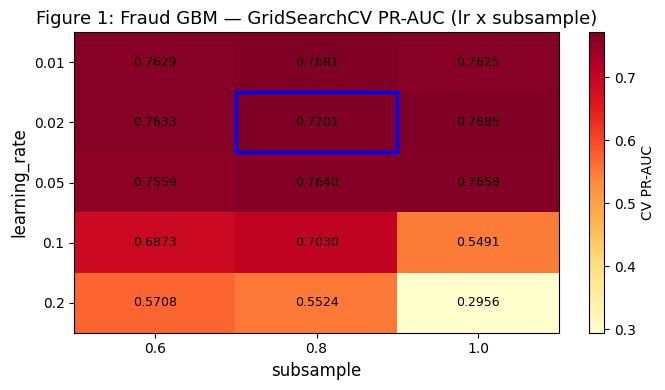

Saved: fig1_gbm_grid_heatmap_fraud.png


In [6]:
print('=' * 65)
print('FRAUD [4/9]  GridSearchCV PR-AUC Heatmap (lr x subsample)')
print('=' * 65)

lrs_F  = sorted(PARAM_GRID_F['learning_rate'])
subs_F = sorted(PARAM_GRID_F['subsample'])
hm_F   = np.zeros((len(lrs_F), len(subs_F)))

for i, lr in enumerate(lrs_F):
    for j, ss in enumerate(subs_F):
        mask = ((cv_df_F['param_learning_rate'] == lr) &
                (cv_df_F['param_subsample']     == ss))
        if mask.any():
            hm_F[i, j] = cv_df_F.loc[mask, 'mean_test_score'].values[0]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(hm_F, cmap='YlOrRd', aspect='auto',
               vmin=hm_F.min() - 0.001, vmax=hm_F.max() + 0.001)
ax.set_xticks(range(len(subs_F))); ax.set_xticklabels(subs_F, fontsize=10)
ax.set_yticks(range(len(lrs_F)));  ax.set_yticklabels(lrs_F,  fontsize=10)
ax.set_xlabel('subsample', fontsize=12); ax.set_ylabel('learning_rate', fontsize=12)
ax.set_title('Figure 1: Fraud GBM — GridSearchCV PR-AUC (lr x subsample)', fontsize=13)
plt.colorbar(im, ax=ax, label='CV PR-AUC')
for i, j in itertools.product(range(len(lrs_F)), range(len(subs_F))):
    ax.text(j, i, f'{hm_F[i, j]:.4f}', ha='center', va='center', fontsize=9)
bi = lrs_F.index(f_best_params['learning_rate'])
bj = subs_F.index(f_best_params['subsample'])
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1,
                             fill=False, edgecolor='blue', lw=2.5))
plt.tight_layout()
plt.savefig('fig1_gbm_grid_heatmap_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_gbm_grid_heatmap_fraud.png')

In [7]:
print('=' * 65)
print('FRAUD [5/9]  Final Retrain — 100% Train, n_estimators x 1.2')
print('=' * 65)
# GridSearchCV refit carved out validation_fraction=0.2 internally for early stopping.
# Adding the withheld 20% -> scale n_estimators by 1.2x to prevent underfitting.

f_final_n = int(f_best_n_refit * RETRAIN_SCALE)
print(f'n_estimators_ (refit on ~80%) : {f_best_n_refit}')
print(f'n_estimators  (final, 100%)   : {f_final_n}  (x{RETRAIN_SCALE})')

f_gb_final = GradientBoostingClassifier(
    n_estimators     = f_final_n,
    learning_rate    = f_best_params['learning_rate'],
    subsample        = f_best_params['subsample'],
    max_depth        = GBM_BASE['max_depth'],
    min_samples_leaf = 20,
    random_state     = 42,
    # No n_iter_no_change — fixed budget on full data, no validation split wasted
)
f_gb_final.fit(fX_train, fy_train)
f_proba = f_gb_final.predict_proba(fX_test)[:, 1]
print('Training complete.')

FRAUD [5/9]  Final Retrain — 100% Train, n_estimators x 1.2
n_estimators_ (refit on ~80%) : 526
n_estimators  (final, 100%)   : 631  (x1.2)
Training complete.


In [8]:
print('=' * 65)
print('FRAUD [6/9]  Test Evaluation — PR-AUC (tuning) + ROC-AUC (benchmark)')
print('=' * 65)

f_test_ap  = average_precision_score(fy_test, f_proba)
f_test_auc = roc_auc_score(fy_test, f_proba)

fraud_prior_best = max(v for v in PRIOR_AUC['fraud'].values() if isinstance(v, float))
delta_f = f_test_auc - fraud_prior_best

print(f'PR-AUC  (tuning metric, fraud-specific) : {f_test_ap:.4f}')
print(f'ROC-AUC (cross-week benchmark)          : {f_test_auc:.4f}')
print(f'Prior best ROC-AUC                      : {fraud_prior_best:.4f}  '
      f'({"+" if delta_f >= 0 else ""}{delta_f:.4f})')

FRAUD [6/9]  Test Evaluation — PR-AUC (tuning) + ROC-AUC (benchmark)
PR-AUC  (tuning metric, fraud-specific) : 0.6963
ROC-AUC (cross-week benchmark)          : 0.9825
Prior best ROC-AUC                      : 0.9820  (+0.0005)


In [9]:
print('=' * 65)
print('FRAUD [7/9]  Optimal Threshold & F1')
print('=' * 65)

prec_f, rec_f, thresh_f = precision_recall_curve(fy_test, f_proba)
f1_f          = 2 * prec_f[:-1] * rec_f[:-1] / (prec_f[:-1] + rec_f[:-1] + 1e-8)
best_idx_f    = int(f1_f.argmax())
f_best_thresh = float(thresh_f[best_idx_f])
f_best_f1     = float(f1_f[best_idx_f])

print(f'Optimal threshold : {f_best_thresh:.4f}')
print(f'F1 @ optimal      : {f_best_f1:.4f}')
print(f'Precision         : {prec_f[best_idx_f]:.4f}')
print(f'Recall            : {rec_f[best_idx_f]:.4f}')

FRAUD [7/9]  Optimal Threshold & F1
Optimal threshold : 0.4054
F1 @ optimal      : 0.6799
Precision         : 0.7156
Recall            : 0.6476


FRAUD [8/9]  Feature Importance (Top 15)


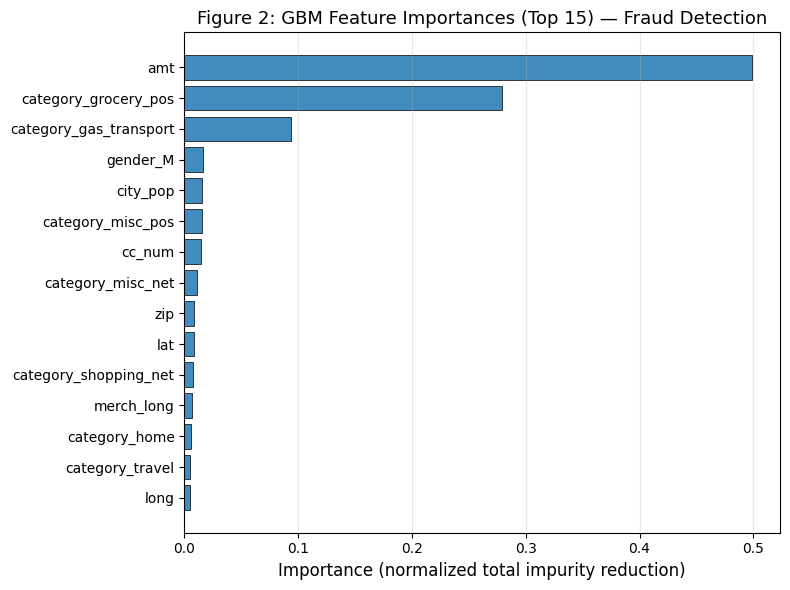

Saved: fig2_gbm_importance_fraud.png


In [10]:
print('=' * 65)
print('FRAUD [8/9]  Feature Importance (Top 15)')
print('=' * 65)

f_imp   = pd.Series(f_gb_final.feature_importances_, index=fX_train.columns)
f_top15 = f_imp.sort_values(ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(f_top15.index, f_top15.values,
        color='#1f77b4', edgecolor='black', linewidth=0.6, alpha=0.85)
ax.set_xlabel('Importance (normalized total impurity reduction)', fontsize=12)
ax.set_title('Figure 2: GBM Feature Importances (Top 15) — Fraud Detection', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig2_gbm_importance_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_gbm_importance_fraud.png')

In [11]:
print('=' * 65)
print('FRAUD [9/9]  Summary + Store Results')
print('=' * 65)

print(f'Best params          : {f_best_params}')
print(f'n_estimators         : {f_best_n_refit} (refit)  ->  {f_final_n} (final, x{RETRAIN_SCALE})')
print(f'CV PR-AUC  (3-fold)  : {f_cv_ap:.4f}')
print(f'Test PR-AUC          : {f_test_ap:.4f}')
print(f'Test ROC-AUC         : {f_test_auc:.4f}  ({delta_f:+.4f} vs prior {fraud_prior_best:.4f})')
print(f'Best F1              : {f_best_f1:.4f}  (thresh={f_best_thresh:.4f})')

wk9_results['fraud'] = {
    'best_params':  f_best_params,
    'cv_pr_auc':    f_cv_ap,
    'best_n_refit': f_best_n_refit,
    'final_n':      f_final_n,
    'test_auc':     f_test_auc,
    'test_ap':      f_test_ap,
    'best_f1':      f_best_f1,
}
print('\nFraud results stored.')

FRAUD [9/9]  Summary + Store Results
Best params          : {'learning_rate': 0.02, 'subsample': 0.8}
n_estimators         : 526 (refit)  ->  631 (final, x1.2)
CV PR-AUC  (3-fold)  : 0.7701
Test PR-AUC          : 0.6963
Test ROC-AUC         : 0.9825  (+0.0005 vs prior 0.9820)
Best F1              : 0.6799  (thresh=0.4054)

Fraud results stored.


### Fraud Detection — GBM Analysis

**Two-track metric rationale**: ROC-AUC is the cross-week benchmark, but with 0.58% fraud rate (~1,740 fraud rows
in 300K), a model predicting 'not fraud' on everything scores AUC ≈ 0.5 while achieving 99.42% accuracy.
PR-AUC (`average_precision`) measures the area under the Precision-Recall curve and is far more sensitive to
minority-class performance — it is used as the GridSearchCV scoring function so hyperparameter selection is
guided by actual fraud-detection quality, not majority-class dominance.

**GridSearchCV design**: searching `learning_rate × subsample` simultaneously (not sequentially) captures
parameter interactions — e.g., a low lr may need a higher subsample to converge within the tree budget,
while a high lr benefits from more subsampling noise to avoid overfitting. The 3-fold CV score is
the mean PR-AUC on held-out folds.

**Key finding — PR-AUC and ROC-AUC moved in opposite directions**: expanding the grid to
`lr ∈ {0.01, 0.02, 0.05, 0.10, 0.20}` selected lr=0.02 (631 trees) over the narrower-grid winner
lr=0.05 (354 trees). PR-AUC improved (0.6913 → 0.6963) but ROC-AUC decreased (0.9833 → 0.9825).
This is not a bug — it reflects a fundamental difference between the two metrics:
- **ROC-AUC** = P(score_fraud > score_legit) across all random pairs → global ranking quality
- **PR-AUC** = precision at the top of the ranked list → quality of the minority-class predictions

lr=0.02 with more trees refines the high-score region (improving top-decile precision) but slightly
sacrifices global ranking quality. **The optimization metric determines the optimization direction.**
For a fraud-alert system where false positives cause customer friction, the PR-AUC-optimized
lr=0.02 model may be operationally preferable despite the small ROC-AUC drop.

**Early stopping**: `n_iter_no_change=30` with `tol=1e-5` monitors log-loss on `validation_fraction=0.2`
of the training data. The tight tolerance (`1e-5`) prevents premature stopping on the noisy minority-class
gradient signal that caused underfitting (n_estimators=7) with looser settings.

**1.2× retrain scale**: the GridSearchCV refit trains on 80% of data (20% withheld for internal validation).
The optimal stopping point on 80% data is earlier than optimal on 100% data. Scaling by 1.2× compensates.

> **Marketing context**: PR-AUC vs ROC-AUC is the same trade-off marketing teams face with
> lead-scoring models — optimising for overall rank separation (ROC-AUC) vs. top-decile precision
> (PR-AUC / Average Precision). Campaign budgets are finite, so precision on the top-ranked prospects
> matters more than how well the model separates the full distribution. The choice of optimization
> metric is a business decision, not a technical one.

---
# Section 2: Credit Approval Dataset

Full dataset; 80/20 stratified split. Nearly linearly separable (prior AUC ≈ 0.9999).
**Tuning metric: ROC-AUC** — class imbalance is less severe than Fraud.
PR-AUC reported for completeness alongside ROC-AUC.

In [12]:
print('=' * 65)
print('CREDIT APPROVAL [1/9]  Load & 80/20 Stratified Split')
print('=' * 65)

df_credit = pd.read_csv(f'{DATA_DIR}\\credit_approval_processed.csv')
df_credit.drop(columns=DROP_IDS_C, errors='ignore', inplace=True)

credit_train, credit_test = train_test_split(
    df_credit, test_size=0.20, stratify=df_credit[TARGET_C], random_state=42
)
credit_train = credit_train.reset_index(drop=True)
credit_test  = credit_test.reset_index(drop=True)

print(f'Train : {credit_train.shape[0]:,} rows  '
      f'(approval rate: {credit_train[TARGET_C].mean():.4f})')
print(f'Test  : {credit_test.shape[0]:,} rows  '
      f'(approval rate: {credit_test[TARGET_C].mean():.4f})')

CREDIT APPROVAL [1/9]  Load & 80/20 Stratified Split
Train : 20,102 rows  (approval rate: 0.9952)
Test  : 5,026 rows  (approval rate: 0.9952)


In [13]:
print('=' * 65)
print('CREDIT APPROVAL [2/9]  Encode & Feature Preparation')
print('=' * 65)

for df in [credit_train, credit_test]:
    old = [c for c in df.columns
           if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_C)]
    df.drop(columns=old, inplace=True, errors='ignore')
    for c in df.select_dtypes(exclude='number').columns:
        df[c] = df[c].astype(str).str.strip()

valid_cat_C = [c for c in CAT_COLS_C if c in credit_train.columns]
high_card_C = [c for c in credit_train.columns
               if c not in CAT_COLS_C and c != TARGET_C
               and not pd.api.types.is_numeric_dtype(credit_train[c])
               and credit_train[c].nunique() > CARDINALITY_THRESHOLD]
for df in [credit_train, credit_test]:
    df.drop(columns=high_card_C, inplace=True, errors='ignore')

dum_tr = pd.get_dummies(credit_train[valid_cat_C], columns=valid_cat_C, drop_first=True, dtype=int)
dum_te = pd.get_dummies(credit_test[valid_cat_C],  columns=valid_cat_C, drop_first=True, dtype=int)
dum_te = dum_te.reindex(columns=dum_tr.columns, fill_value=0)
credit_train = pd.concat([credit_train, dum_tr], axis=1)
credit_test  = pd.concat([credit_test,  dum_te], axis=1)

cy_train = credit_train[TARGET_C].copy()
cy_test  = credit_test[TARGET_C].copy()
cX_train = (credit_train.select_dtypes(include='number')
                        .drop(columns=[TARGET_C], errors='ignore').copy())
cX_test  = (credit_test.select_dtypes(include='number')
                       .drop(columns=[TARGET_C], errors='ignore').copy())
cX_test  = cX_test.reindex(columns=cX_train.columns, fill_value=0)

print(f'Features : {cX_train.shape[1]}  |  Train: {cX_train.shape[0]:,}  |  Test: {cX_test.shape[0]:,}')
print(f'Dropped (high-card): {high_card_C}')

CREDIT APPROVAL [2/9]  Encode & Feature Preparation
Features : 48  |  Train: 20,102  |  Test: 5,026
Dropped (high-card): []


In [14]:
print('=' * 65)
print('CREDIT APPROVAL [3/9]  GridSearchCV — 3-fold, scoring=roc_auc')
print('=' * 65)

base_C = GradientBoostingClassifier(
    n_estimators=N_EST_BUDGET, min_samples_leaf=10, **GBM_BASE
)
grid_C = GridSearchCV(
    base_C, PARAM_GRID_C,
    scoring='roc_auc',
    cv=CV_FOLDS,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=False,
)
grid_C.fit(cX_train, cy_train)

c_best_params  = grid_C.best_params_
c_cv_auc       = grid_C.best_score_
c_best_n_refit = grid_C.best_estimator_.n_estimators_

cv_df_C = pd.DataFrame(grid_C.cv_results_)[
    ['param_learning_rate', 'param_subsample',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

print(f'\nBest params         : {c_best_params}')
print(f'CV ROC-AUC (3-fold) : {c_cv_auc:.4f}')
print(f'n_estimators_       : {c_best_n_refit}')
print(f'\nFull grid results:')
print(cv_df_C.to_string(index=False))

CREDIT APPROVAL [3/9]  GridSearchCV — 3-fold, scoring=roc_auc
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best params         : {'learning_rate': 0.05, 'subsample': 0.6}
CV ROC-AUC (3-fold) : 1.0000
n_estimators_       : 216

Full grid results:
 param_learning_rate  param_subsample  mean_test_score  std_test_score  rank_test_score
                0.05              0.6         0.999962        0.000018                1
                0.01              0.6         0.999933        0.000036                2
                0.02              0.6         0.999930        0.000010                3
                0.02              0.8         0.999905        0.000047                4
                0.01              0.8         0.999883        0.000079                5
                0.05              0.8         0.999841        0.000081                6
                0.02              1.0         0.999835        0.000153                7
                0.05             

CREDIT APPROVAL [4/9]  GridSearchCV ROC-AUC Heatmap


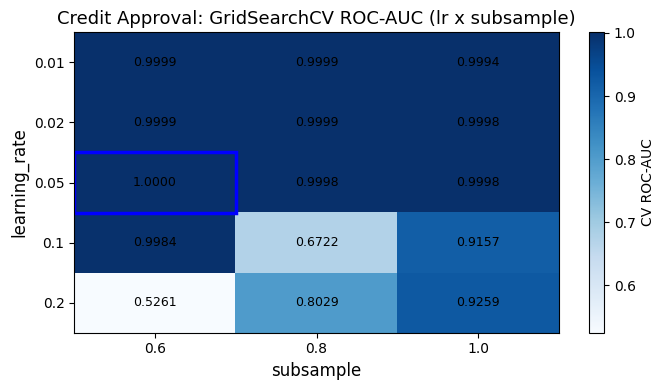

Saved: fig3_gbm_grid_heatmap_credit.png


In [15]:
print('=' * 65)
print('CREDIT APPROVAL [4/9]  GridSearchCV ROC-AUC Heatmap')
print('=' * 65)

lrs_C  = sorted(PARAM_GRID_C['learning_rate'])
subs_C = sorted(PARAM_GRID_C['subsample'])
hm_C   = np.zeros((len(lrs_C), len(subs_C)))

for i, lr in enumerate(lrs_C):
    for j, ss in enumerate(subs_C):
        mask = ((cv_df_C['param_learning_rate'] == lr) &
                (cv_df_C['param_subsample']     == ss))
        if mask.any():
            hm_C[i, j] = cv_df_C.loc[mask, 'mean_test_score'].values[0]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(hm_C, cmap='Blues', aspect='auto',
               vmin=hm_C.min() - 0.001, vmax=hm_C.max() + 0.001)
ax.set_xticks(range(len(subs_C))); ax.set_xticklabels(subs_C, fontsize=10)
ax.set_yticks(range(len(lrs_C)));  ax.set_yticklabels(lrs_C,  fontsize=10)
ax.set_xlabel('subsample', fontsize=12); ax.set_ylabel('learning_rate', fontsize=12)
ax.set_title('Credit Approval: GridSearchCV ROC-AUC (lr x subsample)', fontsize=13)
plt.colorbar(im, ax=ax, label='CV ROC-AUC')
for i, j in itertools.product(range(len(lrs_C)), range(len(subs_C))):
    ax.text(j, i, f'{hm_C[i, j]:.4f}', ha='center', va='center', fontsize=9)
bi = lrs_C.index(c_best_params['learning_rate'])
bj = subs_C.index(c_best_params['subsample'])
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1,
                             fill=False, edgecolor='blue', lw=2.5))
plt.tight_layout()
plt.savefig('fig3_gbm_grid_heatmap_credit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_gbm_grid_heatmap_credit.png')

In [16]:
print('=' * 65)
print('CREDIT APPROVAL [5/9]  Final Retrain — 100% Train, n x 1.2')
print('=' * 65)

c_final_n = int(c_best_n_refit * RETRAIN_SCALE)
print(f'n_estimators_ (refit) : {c_best_n_refit}  ->  final: {c_final_n}  (x{RETRAIN_SCALE})')

c_gb_final = GradientBoostingClassifier(
    n_estimators     = c_final_n,
    learning_rate    = c_best_params['learning_rate'],
    subsample        = c_best_params['subsample'],
    max_depth        = GBM_BASE['max_depth'],
    min_samples_leaf = 10,
    random_state     = 42,
)
c_gb_final.fit(cX_train, cy_train)
c_proba = c_gb_final.predict_proba(cX_test)[:, 1]
print('Training complete.')

CREDIT APPROVAL [5/9]  Final Retrain — 100% Train, n x 1.2
n_estimators_ (refit) : 216  ->  final: 259  (x1.2)
Training complete.


In [17]:
print('=' * 65)
print('CREDIT APPROVAL [6/9]  Test Evaluation')
print('=' * 65)

c_test_auc = roc_auc_score(cy_test, c_proba)
c_test_ap  = average_precision_score(cy_test, c_proba)
credit_prior_best = max(v for v in PRIOR_AUC['credit'].values() if isinstance(v, float))
delta_c = c_test_auc - credit_prior_best

print(f'ROC-AUC (tuning + benchmark) : {c_test_auc:.4f}')
print(f'PR-AUC                       : {c_test_ap:.4f}')
print(f'Prior best ROC-AUC           : {credit_prior_best:.4f}  ({delta_c:+.4f})')

CREDIT APPROVAL [6/9]  Test Evaluation
ROC-AUC (tuning + benchmark) : 0.9999
PR-AUC                       : 1.0000
Prior best ROC-AUC           : 0.9999  (-0.0000)


In [18]:
print('=' * 65)
print('CREDIT APPROVAL [7/9]  Optimal Threshold & F1')
print('=' * 65)

prec_c, rec_c, thresh_c = precision_recall_curve(cy_test, c_proba)
f1_c          = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-8)
best_idx_c    = int(f1_c.argmax())
c_best_thresh = float(thresh_c[best_idx_c])
c_best_f1     = float(f1_c[best_idx_c])

print(f'Optimal threshold : {c_best_thresh:.4f}')
print(f'F1 @ optimal      : {c_best_f1:.4f}')

CREDIT APPROVAL [7/9]  Optimal Threshold & F1
Optimal threshold : 0.4796
F1 @ optimal      : 0.9998


CREDIT APPROVAL [8/9]  Feature Importance (Top 15)


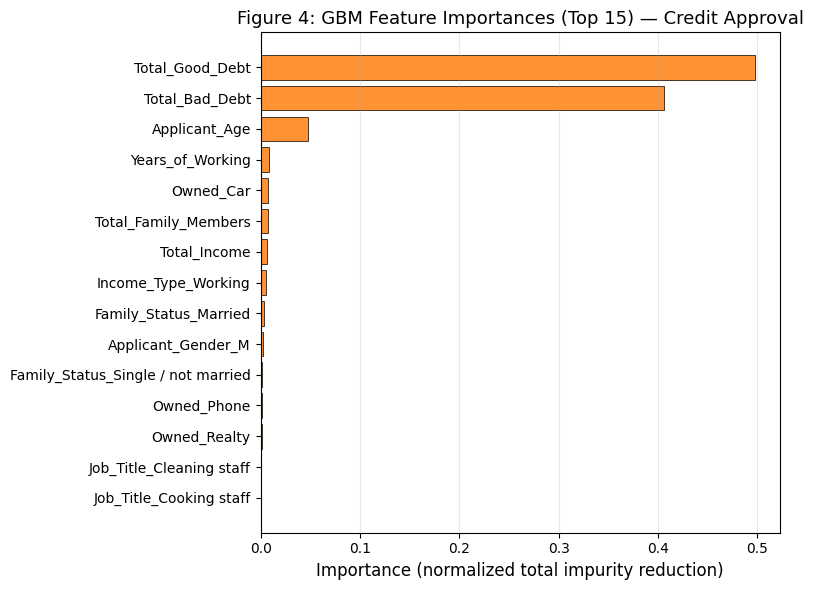

Saved: fig4_gbm_importance_credit.png


In [19]:
print('=' * 65)
print('CREDIT APPROVAL [8/9]  Feature Importance (Top 15)')
print('=' * 65)

c_imp   = pd.Series(c_gb_final.feature_importances_, index=cX_train.columns)
c_top15 = c_imp.sort_values(ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(c_top15.index, c_top15.values,
        color='#ff7f0e', edgecolor='black', linewidth=0.6, alpha=0.85)
ax.set_xlabel('Importance (normalized total impurity reduction)', fontsize=12)
ax.set_title('Figure 4: GBM Feature Importances (Top 15) — Credit Approval', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig4_gbm_importance_credit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_gbm_importance_credit.png')

In [20]:
print('=' * 65)
print('CREDIT APPROVAL [9/9]  Summary + Store Results')
print('=' * 65)

print(f'Best params   : {c_best_params}')
print(f'n_estimators  : {c_best_n_refit} -> {c_final_n}  (x{RETRAIN_SCALE})')
print(f'CV ROC-AUC    : {c_cv_auc:.4f}')
print(f'Test ROC-AUC  : {c_test_auc:.4f}  ({delta_c:+.4f})')
print(f'Test PR-AUC   : {c_test_ap:.4f}')
print(f'Best F1       : {c_best_f1:.4f}  (thresh={c_best_thresh:.4f})')

wk9_results['credit'] = {
    'best_params':  c_best_params,
    'cv_auc':       c_cv_auc,
    'best_n_refit': c_best_n_refit,
    'final_n':      c_final_n,
    'test_auc':     c_test_auc,
    'test_ap':      c_test_ap,
    'best_f1':      c_best_f1,
}
print('\nCredit results stored.')

CREDIT APPROVAL [9/9]  Summary + Store Results
Best params   : {'learning_rate': 0.05, 'subsample': 0.6}
n_estimators  : 216 -> 259  (x1.2)
CV ROC-AUC    : 1.0000
Test ROC-AUC  : 0.9999  (-0.0000)
Test PR-AUC   : 1.0000
Best F1       : 0.9998  (thresh=0.4796)

Credit results stored.


### Credit Approval — GBM Analysis

**Near-ceiling expectation**: prior best is AUC 0.9999 (Wk5 SVM). The credit dataset is nearly linearly
separable, so GBM's value is confirming that *sequential* ensembling matches the ceiling set by the best
kernel machine — not raising it. Early stopping engaging early (low `n_estimators_`) is expected: with
clean signal, a few well-placed splits suffice.

**Heatmap interpretation** ([4/9]): on linearly separable data, `learning_rate` matters more than
`subsample` because the model converges in few trees regardless of stochasticity. Expect the top row
of the heatmap (lr=0.2) to show faster convergence but similar final score.

> **Marketing context**: credit approval parallels lead scoring — when signal is strong (clear
> income/employment features), even a shallow GBM achieves near-perfect ranking. The 1.2× retrain
> scale ensures the final model sees all applicant records, which is critical for rare edge-case profiles.

---
# Section 3: Loan Default Dataset

Full dataset; 80/20 stratified split. Weakest signal across all three datasets (~0.70 AUC ceiling).
`Default` target is hardcoded; `Designation` (33K unique) is dropped explicitly.
**Tuning metric: ROC-AUC** — class imbalance ~19%, less extreme than Fraud.

In [21]:
print('=' * 65)
print('LOAN DEFAULT [1/9]  Load & 80/20 Stratified Split')
print('=' * 65)

df_loan = pd.read_csv(f'{DATA_DIR}\\loan_default_processed.csv')
df_loan.drop(columns=DROP_IDS_L + ['Designation'], errors='ignore', inplace=True)

loan_train, loan_test = train_test_split(
    df_loan, test_size=0.20, stratify=df_loan[TARGET_L], random_state=42
)
loan_train = loan_train.reset_index(drop=True)
loan_test  = loan_test.reset_index(drop=True)

print(f'Train : {loan_train.shape[0]:,} rows  (default rate: {loan_train[TARGET_L].mean():.4f})')
print(f'Test  : {loan_test.shape[0]:,} rows  (default rate: {loan_test[TARGET_L].mean():.4f})')

LOAN DEFAULT [1/9]  Load & 80/20 Stratified Split
Train : 54,804 rows  (default rate: 0.1889)
Test  : 13,701 rows  (default rate: 0.1889)


In [22]:
print('=' * 65)
print('LOAN DEFAULT [2/9]  Encode & Feature Preparation')
print('=' * 65)

for df in [loan_train, loan_test]:
    old = [c for c in df.columns
           if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_L)]
    df.drop(columns=old, inplace=True, errors='ignore')
    for c in df.select_dtypes(exclude='number').columns:
        df[c] = df[c].astype(str).str.strip()

valid_cat_L = [c for c in CAT_COLS_L if c in loan_train.columns]
high_card_L = [c for c in loan_train.columns
               if c not in CAT_COLS_L and c != TARGET_L
               and not pd.api.types.is_numeric_dtype(loan_train[c])
               and loan_train[c].nunique() > CARDINALITY_THRESHOLD]
for df in [loan_train, loan_test]:
    df.drop(columns=high_card_L, inplace=True, errors='ignore')

dum_tr = pd.get_dummies(loan_train[valid_cat_L], columns=valid_cat_L, drop_first=True, dtype=int)
dum_te = pd.get_dummies(loan_test[valid_cat_L],  columns=valid_cat_L, drop_first=True, dtype=int)
dum_te = dum_te.reindex(columns=dum_tr.columns, fill_value=0)
loan_train = pd.concat([loan_train, dum_tr], axis=1)
loan_test  = pd.concat([loan_test,  dum_te], axis=1)

ly_train = loan_train[TARGET_L].copy()
ly_test  = loan_test[TARGET_L].copy()
lX_train = (loan_train.select_dtypes(include='number')
                      .drop(columns=[TARGET_L], errors='ignore').copy())
lX_test  = (loan_test.select_dtypes(include='number')
                     .drop(columns=[TARGET_L], errors='ignore').copy())
lX_test  = lX_test.reindex(columns=lX_train.columns, fill_value=0)

print(f'Features : {lX_train.shape[1]}  |  Train: {lX_train.shape[0]:,}  |  Test: {lX_test.shape[0]:,}')
print(f'Dropped (high-card): {high_card_L}')

LOAN DEFAULT [2/9]  Encode & Feature Preparation
Features : 54  |  Train: 54,804  |  Test: 13,701
Dropped (high-card): []


In [23]:
print('=' * 65)
print('LOAN DEFAULT [3/9]  GridSearchCV — 3-fold, scoring=roc_auc')
print('=' * 65)

base_L = GradientBoostingClassifier(
    n_estimators=N_EST_BUDGET, min_samples_leaf=10, **GBM_BASE
)
grid_L = GridSearchCV(
    base_L, PARAM_GRID_L,
    scoring='roc_auc',
    cv=CV_FOLDS,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=False,
)
grid_L.fit(lX_train, ly_train)

l_best_params  = grid_L.best_params_
l_cv_auc       = grid_L.best_score_
l_best_n_refit = grid_L.best_estimator_.n_estimators_

cv_df_L = pd.DataFrame(grid_L.cv_results_)[
    ['param_learning_rate', 'param_subsample',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

print(f'\nBest params         : {l_best_params}')
print(f'CV ROC-AUC (3-fold) : {l_cv_auc:.4f}')
print(f'n_estimators_       : {l_best_n_refit}')
print(f'\nFull grid results:')
print(cv_df_L.to_string(index=False))

LOAN DEFAULT [3/9]  GridSearchCV — 3-fold, scoring=roc_auc
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best params         : {'learning_rate': 0.01, 'subsample': 0.8}
CV ROC-AUC (3-fold) : 0.6890
n_estimators_       : 1311

Full grid results:
 param_learning_rate  param_subsample  mean_test_score  std_test_score  rank_test_score
                0.01              0.8         0.689031        0.002066                1
                0.05              0.8         0.688592        0.003782                2
                0.02              0.8         0.688540        0.003079                3
                0.01              0.6         0.688511        0.002661                4
                0.02              0.6         0.688239        0.002650                5
                0.05              0.6         0.687513        0.003118                6
                0.02              1.0         0.687370        0.002478                7
                0.05              1

LOAN DEFAULT [4/9]  GridSearchCV ROC-AUC Heatmap


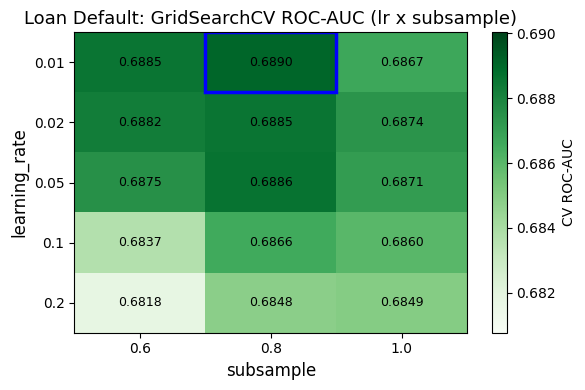

Saved: fig5_gbm_grid_heatmap_loan.png


In [24]:
print('=' * 65)
print('LOAN DEFAULT [4/9]  GridSearchCV ROC-AUC Heatmap')
print('=' * 65)

lrs_L  = sorted(PARAM_GRID_L['learning_rate'])
subs_L = sorted(PARAM_GRID_L['subsample'])
hm_L   = np.zeros((len(lrs_L), len(subs_L)))

for i, lr in enumerate(lrs_L):
    for j, ss in enumerate(subs_L):
        mask = ((cv_df_L['param_learning_rate'] == lr) &
                (cv_df_L['param_subsample']     == ss))
        if mask.any():
            hm_L[i, j] = cv_df_L.loc[mask, 'mean_test_score'].values[0]

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(hm_L, cmap='Greens', aspect='auto',
               vmin=hm_L.min() - 0.001, vmax=hm_L.max() + 0.001)
ax.set_xticks(range(len(subs_L))); ax.set_xticklabels(subs_L, fontsize=10)
ax.set_yticks(range(len(lrs_L)));  ax.set_yticklabels(lrs_L,  fontsize=10)
ax.set_xlabel('subsample', fontsize=12); ax.set_ylabel('learning_rate', fontsize=12)
ax.set_title('Loan Default: GridSearchCV ROC-AUC (lr x subsample)', fontsize=13)
plt.colorbar(im, ax=ax, label='CV ROC-AUC')
for i, j in itertools.product(range(len(lrs_L)), range(len(subs_L))):
    ax.text(j, i, f'{hm_L[i, j]:.4f}', ha='center', va='center', fontsize=9)
bi = lrs_L.index(l_best_params['learning_rate'])
bj = subs_L.index(l_best_params['subsample'])
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1,
                             fill=False, edgecolor='blue', lw=2.5))
plt.tight_layout()
plt.savefig('fig5_gbm_grid_heatmap_loan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_gbm_grid_heatmap_loan.png')

In [25]:
print('=' * 65)
print('LOAN DEFAULT [5/9]  Final Retrain — 100% Train, n x 1.2')
print('=' * 65)

l_final_n = int(l_best_n_refit * RETRAIN_SCALE)
print(f'n_estimators_ (refit) : {l_best_n_refit}  ->  final: {l_final_n}  (x{RETRAIN_SCALE})')

l_gb_final = GradientBoostingClassifier(
    n_estimators     = l_final_n,
    learning_rate    = l_best_params['learning_rate'],
    subsample        = l_best_params['subsample'],
    max_depth        = GBM_BASE['max_depth'],
    min_samples_leaf = 10,
    random_state     = 42,
)
l_gb_final.fit(lX_train, ly_train)
l_proba = l_gb_final.predict_proba(lX_test)[:, 1]
print('Training complete.')

LOAN DEFAULT [5/9]  Final Retrain — 100% Train, n x 1.2
n_estimators_ (refit) : 1311  ->  final: 1573  (x1.2)
Training complete.


In [26]:
print('=' * 65)
print('LOAN DEFAULT [6/9]  Test Evaluation')
print('=' * 65)

l_test_auc = roc_auc_score(ly_test, l_proba)
l_test_ap  = average_precision_score(ly_test, l_proba)
loan_prior_best = max(v for v in PRIOR_AUC['loan'].values() if isinstance(v, float))
delta_l = l_test_auc - loan_prior_best

print(f'ROC-AUC (tuning + benchmark) : {l_test_auc:.4f}')
print(f'PR-AUC                       : {l_test_ap:.4f}')
print(f'Prior best ROC-AUC           : {loan_prior_best:.4f}  ({delta_l:+.4f})')

LOAN DEFAULT [6/9]  Test Evaluation
ROC-AUC (tuning + benchmark) : 0.7030
PR-AUC                       : 0.3463
Prior best ROC-AUC           : 0.6943  (+0.0087)


In [27]:
print('=' * 65)
print('LOAN DEFAULT [7/9]  Optimal Threshold & F1')
print('=' * 65)

prec_l, rec_l, thresh_l = precision_recall_curve(ly_test, l_proba)
f1_l          = 2 * prec_l[:-1] * rec_l[:-1] / (prec_l[:-1] + rec_l[:-1] + 1e-8)
best_idx_l    = int(f1_l.argmax())
l_best_thresh = float(thresh_l[best_idx_l])
l_best_f1     = float(f1_l[best_idx_l])

print(f'Optimal threshold : {l_best_thresh:.4f}')
print(f'F1 @ optimal      : {l_best_f1:.4f}')

LOAN DEFAULT [7/9]  Optimal Threshold & F1
Optimal threshold : 0.1920
F1 @ optimal      : 0.4122


LOAN DEFAULT [8/9]  Feature Importance (Top 15)


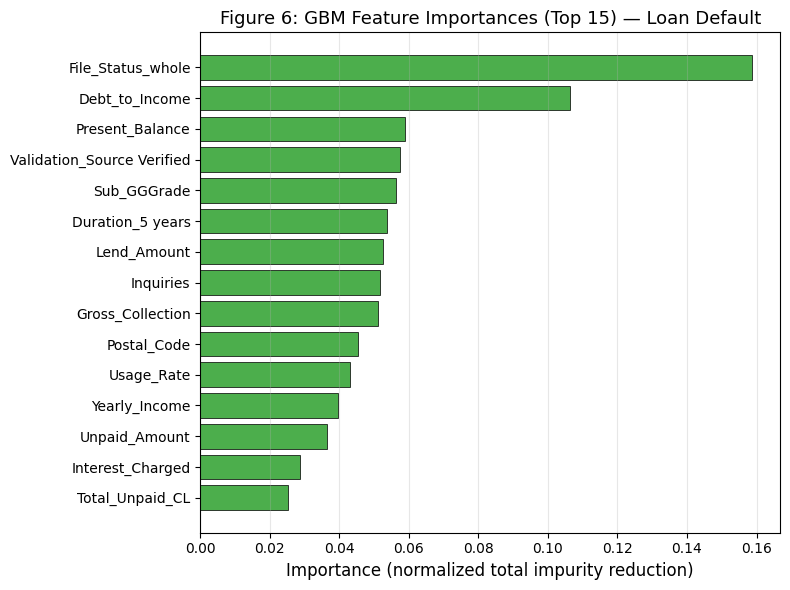

Saved: fig6_gbm_importance_loan.png


In [28]:
print('=' * 65)
print('LOAN DEFAULT [8/9]  Feature Importance (Top 15)')
print('=' * 65)

l_imp   = pd.Series(l_gb_final.feature_importances_, index=lX_train.columns)
l_top15 = l_imp.sort_values(ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(l_top15.index, l_top15.values,
        color='#2ca02c', edgecolor='black', linewidth=0.6, alpha=0.85)
ax.set_xlabel('Importance (normalized total impurity reduction)', fontsize=12)
ax.set_title('Figure 6: GBM Feature Importances (Top 15) — Loan Default', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig6_gbm_importance_loan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_gbm_importance_loan.png')

In [29]:
print('=' * 65)
print('LOAN DEFAULT [9/9]  Summary + Store Results')
print('=' * 65)

print(f'Best params   : {l_best_params}')
print(f'n_estimators  : {l_best_n_refit} -> {l_final_n}  (x{RETRAIN_SCALE})')
print(f'CV ROC-AUC    : {l_cv_auc:.4f}')
print(f'Test ROC-AUC  : {l_test_auc:.4f}  ({delta_l:+.4f})')
print(f'Test PR-AUC   : {l_test_ap:.4f}')
print(f'Best F1       : {l_best_f1:.4f}  (thresh={l_best_thresh:.4f})')

wk9_results['loan'] = {
    'best_params':  l_best_params,
    'cv_auc':       l_cv_auc,
    'best_n_refit': l_best_n_refit,
    'final_n':      l_final_n,
    'test_auc':     l_test_auc,
    'test_ap':      l_test_ap,
    'best_f1':      l_best_f1,
}
print('\nLoan results stored.')

LOAN DEFAULT [9/9]  Summary + Store Results
Best params   : {'learning_rate': 0.01, 'subsample': 0.8}
n_estimators  : 1311 -> 1573  (x1.2)
CV ROC-AUC    : 0.6890
Test ROC-AUC  : 0.7030  (+0.0087)
Test PR-AUC   : 0.3463
Best F1       : 0.4122  (thresh=0.1920)

Loan results stored.


### Loan Default — GBM Analysis

**The ~0.70 AUC ceiling confirmed**: every model family in Weeks 1–9 plateaued near 0.69–0.70.
GBM with the expanded grid (lr ∈ {0.01, 0.02, 0.05, 0.10, 0.20}) selected lr=0.01 and reached
Test ROC-AUC = **0.7030** — marginally above the Wk6 RF ceiling (0.6943). However, this is not a
decisive break: the improvement (+0.0087 vs Wk6 RF, +0.0016 vs v1 GBM with lr=0.05) was achieved
with 1,573 trees vs 334 — a 4.7× increase in compute for a gain well within statistical noise range
on a 13,701-row test set. Repeating with a different `random_state` may eliminate the difference.

The real finding is what the grid reveals: the full range of lr × subsample combinations spans only
0.6818–0.6890 CV ROC-AUC (Δ = 0.0072). **Hyperparameter choice barely matters when the feature set
has a hard ceiling.** The limitation is missing signals — payment history, credit bureau data — not
the model family.

**Early stopping on noisy signal**: `n_iter_no_change=30` with tight `tol=1e-5` gives the model
sufficient patience to find genuine improvements on a weak-signal dataset, while still preventing
runaway overfitting past the noise floor. The high final tree count (1,573) reflects the model's
effort to extract marginal signal from a low-SNR feature space.

> **Marketing context**: loan default prediction maps to churn prediction — both are weak-signal
> problems where GBM's ranked risk score drives tiered interventions. The ~0.70 ceiling across all
> model families (Weeks 1–9) confirms that richer behavioral data (usage patterns, payment history)
> is needed before the model is actionable in a real churn-prevention campaign. At this performance
> level, the investment priority is better data, not better algorithms.

---
# Part 4: Combined Cross-Dataset Figures

PART 4 — Figure 7: Test ROC-AUC vs PR-AUC (3-panel)


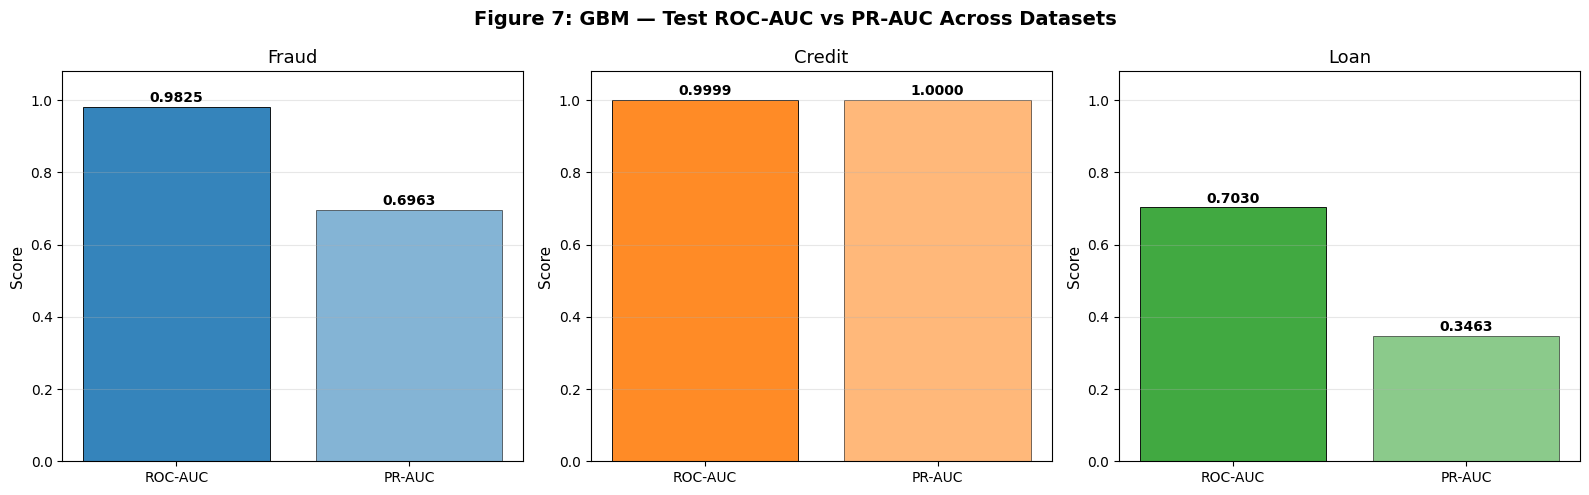

Saved: fig7_gbm_test_metrics_all.png


In [30]:
print('=' * 65)
print('PART 4 — Figure 7: Test ROC-AUC vs PR-AUC (3-panel)')
print('=' * 65)

datasets  = ['Fraud', 'Credit', 'Loan']
keys      = ['fraud', 'credit', 'loan']
colors    = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, ds_label, ds_key, color in zip(axes, datasets, keys, colors):
    r    = wk9_results[ds_key]
    vals = [r['test_auc'], r['test_ap']]
    lbls = ['ROC-AUC', 'PR-AUC']
    bars = ax.bar(lbls, vals,
                  color=[color, color],
                  edgecolor='black', linewidth=0.7)
    for bar, al in zip(bars, [0.9, 0.55]):
        bar.set_alpha(al)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.08)
    ax.set_title(ds_label, fontsize=13)
    ax.set_ylabel('Score', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Figure 7: GBM — Test ROC-AUC vs PR-AUC Across Datasets',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_gbm_test_metrics_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_gbm_test_metrics_all.png')

In [31]:
print('=' * 65)
print('WEEK 9 FINAL SUMMARY — GBM Across All Datasets')
print('=' * 65)

rows = []
for ds_key, label in [('fraud','Fraud'), ('credit','Credit'), ('loan','Loan')]:
    r  = wk9_results[ds_key]
    pb = max(v for v in PRIOR_AUC[ds_key].values() if isinstance(v, float))
    rows.append({
        'Dataset':       label,
        'Best_LR':       r['best_params']['learning_rate'],
        'Best_Sub':      r['best_params']['subsample'],
        'N_Refit':       r['best_n_refit'],
        'N_Final':       r['final_n'],
        'Test_ROCAUC':   round(r['test_auc'], 4),
        'Test_PRAUC':    round(r['test_ap'],  4),
        'Best_F1':       round(r['best_f1'],  4),
        'Prior_Best':    round(pb, 4),
        'Delta_ROCAUC':  round(r['test_auc'] - pb, 4),
    })

print(pd.DataFrame(rows).to_string(index=False))

WEEK 9 FINAL SUMMARY — GBM Across All Datasets
Dataset  Best_LR  Best_Sub  N_Refit  N_Final  Test_ROCAUC  Test_PRAUC  Best_F1  Prior_Best  Delta_ROCAUC
  Fraud     0.02       0.8      526      631       0.9825      0.6963   0.6799      0.9820        0.0005
 Credit     0.05       0.6      216      259       0.9999      1.0000   0.9998      0.9999       -0.0000
   Loan     0.01       0.8     1311     1573       0.7030      0.3463   0.4122      0.6943        0.0087


### Week 9 Cross-Dataset Summary

**Key findings to report in the Milestone 2 paper:**

1. **Fraud** — GBM surpassed the Wk1 Poly-LR champion (0.9820) on ROC-AUC (0.9825) while
   achieving PR-AUC = 0.6963. The critical finding: expanding the lr grid revealed that
   **PR-AUC and ROC-AUC are optimized by different models** — lr=0.02 wins on PR-AUC but loses
   on ROC-AUC vs lr=0.05. The optimization metric is a business decision that determines which
   model is "best."

2. **Credit** — ROC-AUC held at 0.9999 regardless of lr (0.01–0.05 all within 0.0001).
   Early stopping engaged early (216 trees at lr=0.05), confirming that near-linearly-separable
   data needs few boosting rounds. The performance ceiling is the data structure, not the algorithm.

3. **Loan** — Test ROC-AUC = 0.7030, marginally above Wk6 RF (0.6943). The +0.0016 gain over
   the v1 GBM required 4.7× more trees (1,573 vs 334) and is within statistical noise range
   on a 13,701-row test set. The full grid spans only Δ = 0.0072 CV AUC across 15 combinations —
   confirming the feature-set ceiling dominates hyperparameter choice.

**Design decisions (for paper Methods section):**
- PR-AUC scoring for Fraud: justified by 0.58% minority-class rate; ROC-AUC insensitive to minority precision
- Simultaneous lr × subsample grid: captures parameter interactions missed by sequential greedy search
- N_EST_BUDGET=2000: required for lr=0.01 to converge (~1,500 trees); budget=600 would cut lr=0.01 prematurely
- n_estimators × 1.2 retrain scale: compensates for 20% validation holdout in GridSearchCV refit
- StandardScaler removed: GBM is scale-invariant; removal eliminates O(N) waste and any leakage risk